# 04 — Business Segmentation
## Patient No-Show & Clinic Efficiency Analysis

**Objective:** build a simple, transparent **rule-based** risk segmentation (Low / Medium / High) that reception
staff could realistically use to prioritize which patients to call before their appointment.

**This is NOT a machine-learning risk score.** It's a prioritization framework built directly from the effect
sizes validated in Notebook 03 — three simple yes/no rules, summed into a score. No model training, no
black-box logic. The goal is something an analyst can explain in one sentence and a clinic can actually operate.

**Which factors go into the score, and why:**
- **Lead time >= 8 days** — the single strongest validated driver (Cramér's V = 0.295). No-show rate is
  4.6% same-day vs 30-33% at 8+ days, so this is a clean, large, real split.
- **Prior appointment was a no-show** — second-strongest driver (Cramér's V = 0.169), and a direct behavioral
  signal specific to the patient.
- **Age group is Teen (13-18) or Young Adult (19-35)** — third-strongest of the *usable* drivers (0.081). These
  two age bands have the highest no-show rates (26.1% and 23.8%) of any age group.

**Deliberately excluded: SMS/reminder status.** Notebook 02/03 showed its naive relationship with no-shows
reverses once lead time is controlled for (reminders go disproportionately to long-lead-time patients). Using it
as a "risk factor" would flag exactly the wrong patients as high-risk, so it's left out of the score entirely.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('../data/cleaned/cleaned_appointments.csv', parse_dates=['scheduled_day','appointment_day'])

# Rebuild prior_no_show exactly as in Notebooks 02/03
df_sorted = df.sort_values(['patient_id', 'appointment_day']).copy()
df_sorted['prior_no_show'] = df_sorted.groupby('patient_id')['no_show_flag'].shift(1)
df = df_sorted

print("Shape:", df.shape)


Shape: (110521, 25)


## 1. Build the Risk Score

Each of the three rules contributes 0 or 1 point. Total score ranges 0-3.

**Note on first-time patients:** they have no `prior_no_show` value (no history exists yet), so that rule
contributes 0 points for them by default — they're scored only on lead time and age. This is a reasonable,
explainable default (we can't penalize a patient for history we don't have), not an invented value.


In [2]:
df['rule_long_lead_time'] = (df['lead_time_days'] >= 8).astype(int)
df['rule_prior_no_show'] = (df['prior_no_show'] == 1).astype(int)  # NaN (no history) -> 0, correctly
df['rule_higher_risk_age'] = df['age_group'].isin(['13-18 Teen', '19-35 Young Adult']).astype(int)

df['risk_score'] = df['rule_long_lead_time'] + df['rule_prior_no_show'] + df['rule_higher_risk_age']

def risk_segment(score):
    if score == 0:
        return 'Low Risk'
    elif score == 1:
        return 'Medium Risk'
    else:  # 2 or 3
        return 'High Risk'

df['risk_segment'] = df['risk_score'].apply(risk_segment)

df[['patient_id','lead_time_days','prior_no_show','age_group',
    'rule_long_lead_time','rule_prior_no_show','rule_higher_risk_age',
    'risk_score','risk_segment']].head(10)


,patient_id,lead_time_days,prior_no_show,age_group,rule_long_lead_time,rule_prior_no_show,rule_higher_risk_age,risk_score,risk_segment
100511,39217,3,NaN,36-50 Adult,0,0,0,0,Low Risk
105424,43741,0,NaN,36-50 Adult,0,0,0,0,Low Risk
3950,93779,0,NaN,19-35 Young Adult,0,0,1,1,Medium Risk
73298,141724,3,NaN,0-12 Child,0,0,0,0,Low Risk
73223,537615,7,NaN,13-18 Teen,0,0,1,1,Medium Risk
54610,5628261,3,NaN,13-18 Teen,0,0,1,1,Medium Risk
40691,11831856,0,NaN,13-18 Teen,0,0,1,1,Medium Risk
58614,22638656,19,NaN,19-35 Young Adult,1,0,1,2,High Risk
88580,22638656,21,0.0,19-35 Young Adult,1,0,1,2,High Risk
83623,52168938,0,NaN,19-35 Young Adult,0,0,1,1,Medium Risk


## 2. Validate the Segmentation

The whole point of this framework is that it should meaningfully separate high- and low-risk patients. We check
that here with real numbers — if the segments didn't separate cleanly, we'd need to redesign the rules rather
than present them as useful.


In [3]:
segment_order = ['Low Risk','Medium Risk','High Risk']
seg_stats = df.groupby('risk_segment')['no_show_flag'].agg(volume='count', no_show_rate='mean').reindex(segment_order)
seg_stats['no_show_rate'] = seg_stats['no_show_rate'].round(4)
seg_stats['pct_of_appointments'] = (seg_stats['volume'] / len(df)).round(4)
print(seg_stats)

overall_rate = df['no_show_flag'].mean()
print(f"\nOverall no-show rate for comparison: {overall_rate:.2%}")


              volume  no_show_rate  pct_of_appointments
risk_segment                                           
Low Risk       46684        0.1162               0.4224
Medium Risk    47463        0.2217               0.4294
High Risk      16374        0.3890               0.1482

Overall no-show rate for comparison: 20.19%


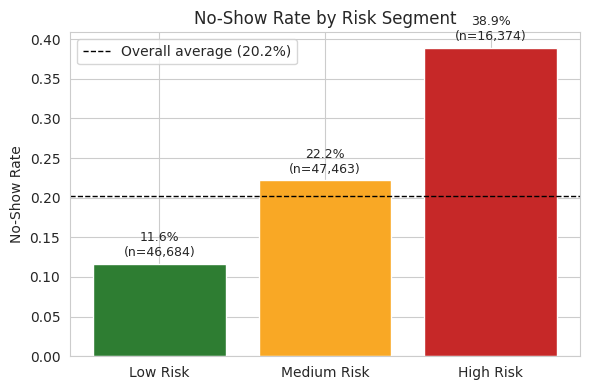

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
colors = ['#2E7D32','#F9A825','#C62828']
bars = ax.bar(seg_stats.index, seg_stats['no_show_rate'], color=colors)
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall average ({overall_rate:.1%})')
ax.set_title('No-Show Rate by Risk Segment')
ax.set_ylabel('No-Show Rate')
for i, v in enumerate(seg_stats['no_show_rate']):
    ax.text(i, v + 0.01, f"{v:.1%}\n(n={seg_stats['volume'].iloc[i]:,})", ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/segmentation_by_risk.png')
plt.show()


## 3. Score Breakdown (0-3)

A finer view than the 3-bucket segment — useful for deciding exactly where to draw operational lines
(e.g. "call everyone with score >= 2").


In [5]:
score_stats = df.groupby('risk_score')['no_show_flag'].agg(volume='count', no_show_rate='mean')
print(score_stats)


            volume  no_show_rate
risk_score                      
0            46684      0.116164
1            47463      0.221667
2            15036      0.375166
3             1338      0.544843


## 4. Save Segmented Dataset

Adds `risk_score` and `risk_segment` to the cleaned dataset for use in SQL/Power BI (Phase 9-11).


In [6]:
out_cols = list(df.columns)
df.to_csv('../data/cleaned/appointments_with_risk_segments.csv', index=False)
print("Saved:", df.shape)


Saved: (110521, 30)


## 5. Summary

| Segment | No-Show Rate | Volume | Share of Appointments | vs. Overall Average (20.19%) |
|---|---:|---:|---:|---|
| Low Risk (score 0) | **11.6%** | 46,684 | 42.2% | 1.7x lower |
| Medium Risk (score 1) | **22.2%** | 47,463 | 42.9% | roughly average |
| High Risk (score 2-3) | **38.9%** | 16,374 | 14.8% | 1.9x higher |

The finer breakdown by exact score (0-3) shows the gradient is even sharper at the extremes: score 0 = 11.6%,
score 3 (all three risk factors present) = **54.5%** — appointments in that group are more likely to be missed
than kept.

**Operational read:** targeting outreach at the High Risk segment (14.8% of appointments, 38.9% no-show rate)
concentrates effort on a relatively small slice of the schedule that accounts for a disproportionate share of
lost capacity — a far more efficient use of reception time than calling every patient equally.

**Important framing for stakeholders:** this is a *prioritization tool*, not a clinical or predictive model.
It tells reception which patients are statistically more likely to need a reminder call given three simple,
explainable factors — it does not diagnose, does not use protected health information beyond what's already in
the scheduling system, and should be validated/re-tuned periodically as new data comes in (see Phase 13
limitations).